Iniciando otimização com algoritmo genético...

Melhores valores estimados:
  - Solid Loading: 249.27 g/L
  - Enzyme Loading: 1.3650 g/L
  - Time: 95.8 h
  - Fitness: -6490.25

Outputs previstos: [ 14.03547  101.15144   72.100235]
Outputs esperados: [99, 190, 25]

Melhores valores estimados:
  - Solid Loading: 249.27 g/L
  - Enzyme Loading: 1.3650 g/L
  - Time: 95.8 h
  - Fitness: -6490.25

Outputs previstos: [ 14.03547  101.15144   72.100235]
Outputs esperados: [99, 190, 25]


Iniciando otimização com algoritmo genético...

Melhores valores estimados:
  - Solid Loading: 249.27 g/L
  - Enzyme Loading: 1.3650 g/L
  - Time: 95.8 h
  - Fitness: -6490.25

Outputs previstos: [ 14.03547  101.15144   72.100235]
Outputs esperados: [99, 190, 25]

Melhores valores estimados:
  - Solid Loading: 249.27 g/L
  - Enzyme Loading: 1.3650 g/L
  - Time: 95.8 h
  - Fitness: -6490.25

Outputs previstos: [ 14.03547  101.15144   72.100235]
Outputs esperados: [99, 190, 25]


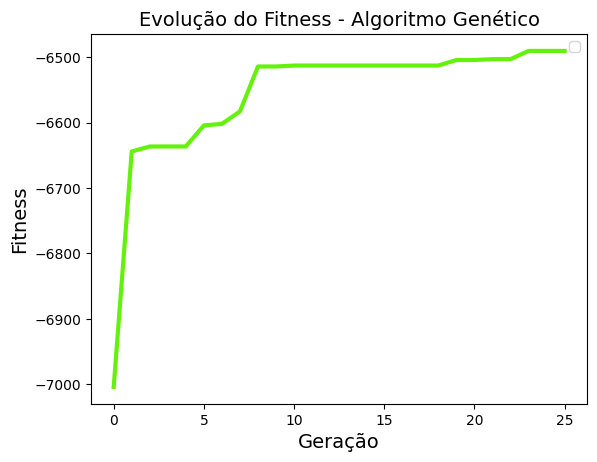

Iniciando otimização com algoritmo genético...

Melhores valores estimados:
  - Solid Loading: 249.27 g/L
  - Enzyme Loading: 1.3650 g/L
  - Time: 95.8 h
  - Fitness: -6490.25

Outputs previstos: [ 14.03547  101.15144   72.100235]
Outputs esperados: [99, 190, 25]

Melhores valores estimados:
  - Solid Loading: 249.27 g/L
  - Enzyme Loading: 1.3650 g/L
  - Time: 95.8 h
  - Fitness: -6490.25

Outputs previstos: [ 14.03547  101.15144   72.100235]
Outputs esperados: [99, 190, 25]


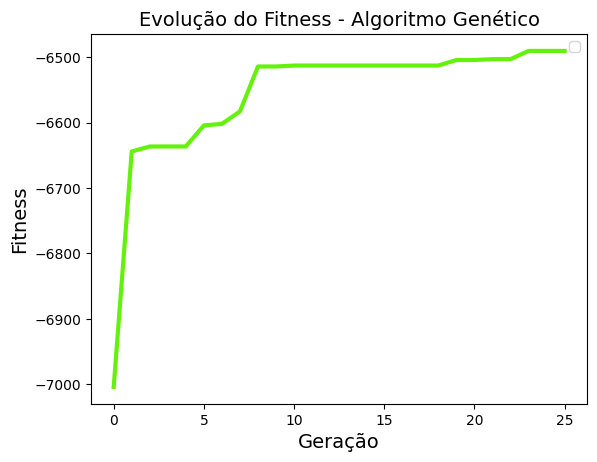

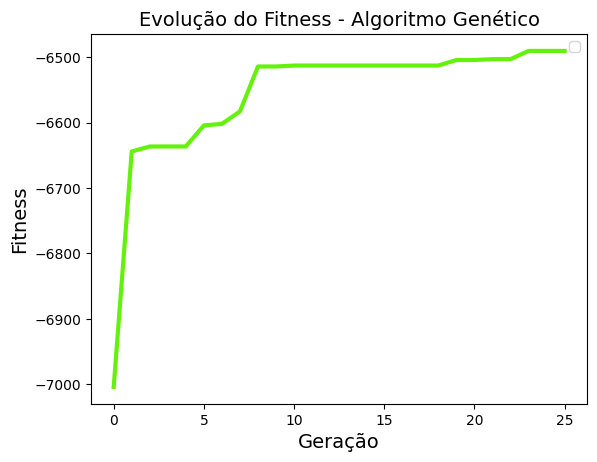

In [ ]:
import tensorflow as tf
import numpy as np
import pygad

def retro_coisa_pretreatment_bagasse():
    return "Isso é uma função de exemplo"

def retro_coisa_pretreatment_straw():
    return "Isso é uma função de exemplo"

# Carregar o modelo pré-treinado
model = tf.keras.models.load_model('modelo_hidrolise_otimizado.keras')

# Parâmetros do problema
NUM_KNOWN_INPUTS = 3      # Número de inputs conhecidos
NUM_UNKNOWN_INPUTS = 3    # Número de inputs desconhecidos a serem estimados
KNOWN_INPUTS = np.array([[0.4, 0.25, 0.35]])  # Valores dos inputs conhecidos

# Definir a função de fitness (PyGAD 2.20.0 requer 3 parâmetros)
def fitness_func(ga_instance, solution, solution_idx):
    # Converter a solução para o formato adequado
    unknown_inputs = np.array([solution], dtype=np.float32)
    
    # Concatenar com os inputs conhecidos para ter o input completo
    full_inputs = np.concatenate([KNOWN_INPUTS, unknown_inputs], axis=1).astype(np.float32)
    
    # Converter para tensor TensorFlow
    full_inputs_tf = tf.convert_to_tensor(full_inputs, dtype=tf.float32)
    
    # Fazer previsão com o modelo
    predictions = model(full_inputs_tf)
    
    # OPÇÃO 1: Se você tem outputs esperados conhecidos
    expected_outputs = tf.constant([[99.0, 190.0, 25.0]], dtype=tf.float32)
    # Minimizar diferença (usar negativo pois PyGAD maximiza)
    prediction_fitness = -tf.reduce_mean(tf.square(predictions - expected_outputs))
    
    # Penalidade para evitar inputs extremos (opcional)
    input_regularization = -0.01 * tf.reduce_sum(tf.square(tf.cast(unknown_inputs, tf.float32)))
    
    fitness = prediction_fitness + input_regularization
    
    return float(fitness.numpy())

# Configurar parâmetros otimizados do algoritmo genético
num_generations = 25      # Aumentar para melhor convergência
num_parents_mating = 30    # 30% da população se reproduz (melhor diversidade)
sol_per_pop = 50
num_genes = NUM_UNKNOWN_INPUTS

# Definir intervalo para os inputs desconhecidos
gene_space = [
    {'low': 50, 'high': 250},   # Solid Loading (g/L)
    {'low': 0.01, 'high': 1.5}, # Enzyme Loading (g/L)
    {'low': 1, 'high': 96}      # Time (h)
]

# Inicializar o PyGAD com parâmetros otimizados
ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       fitness_func=fitness_func,
                       sol_per_pop=sol_per_pop,
                       num_genes=num_genes,
                       gene_space=gene_space,
                       mutation_type="random",
                       mutation_percent_genes=20,      # Maior diversidade genética
                       keep_parents=5,                 # Elitismo: manter os 5 melhores
                       crossover_type="two_points",    # Crossover mais sofisticado
                       parent_selection_type="sss",    # Steady-state selection
                       random_seed=42,                 # Para reprodutibilidade
                       stop_criteria=["saturate_10"])  # Parar se não melhorar por 10 gerações

# Executar o algoritmo genético
print("Iniciando otimização com algoritmo genético...")
ga_instance.run()

# Obter a melhor solução encontrada
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"\nMelhores valores estimados:")
print(f"  - Solid Loading: {solution[0]:.2f} g/L")
print(f"  - Enzyme Loading: {solution[1]:.4f} g/L") 
print(f"  - Time: {solution[2]:.1f} h")
print(f"  - Fitness: {solution_fitness:.2f}")

# Usar os valores estimados para fazer uma previsão completa
unknown_inputs = np.array([solution])
full_inputs = np.concatenate([KNOWN_INPUTS, unknown_inputs], axis=1)
full_inputs_tf = tf.convert_to_tensor(full_inputs, dtype=tf.float32)
final_predictions = model(full_inputs_tf)
print(f"\nOutputs previstos: {final_predictions.numpy()[0]}")
print(f"Outputs esperados: [99, 190, 25]")

# Plotar evolução do fitness ao longo das gerações
ga_instance.plot_fitness(title="Evolução do Fitness - Algoritmo Genético",
                        xlabel="Geração", 
                        ylabel="Fitness")

In [ ]:
# Aqui vai usar o q o ANN-Based back optimization achou pra calcular o rendimento

: 